# PyTorch DataLoader for DST Data - Solutions

This notebook contains complete solutions to the DataLoader exercises.

## What is a DataLoader?

A **DataLoader** is a tool that:
1. **Loads data in batches** - Instead of loading all data at once, load small groups (e.g., 32 events)
2. **Shuffles data** - Randomizes order for better training
3. **Works with GPU** - Automatically moves data to GPU if available
4. **Handles complex data** - Can work with graphs, variable-length sequences, etc.

## Setup

In [1]:
import torch
import h5py
import numpy as np
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

## Part 1: Understanding the HDF5 Structure

### Exercise 1.1: Inspect the HDF5 File

In [3]:
# Path to your HDF5 file from previous exercise
hdf5_path = "/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019/handson/handson_new/vlen_outres2.h5"

# Open and inspect the file
with h5py.File(hdf5_path, 'r') as f:
    print("Available datasets:")
    print(f"Keys: {list(f.keys())}\n")
    
    print("Dataset shapes:")
    for key in f.keys():
        print(f"  {key:25s}: {f[key].shape} {f[key].dtype}")

Available datasets:
Keys: ['arrival_times', 'detector_ids', 'detector_positions', 'energy', 'hit_offsets', 'hit_tt_offsets', 'mass_number', 'nfold', 'pulse_area', 'shower_axis', 'shower_core', 'status', 'std_recon_border_distance', 'std_recon_border_distance_tshape', 'std_recon_curvature', 'std_recon_curvature_err', 'std_recon_energy', 'std_recon_geom_chi2', 'std_recon_geom_ndof', 'std_recon_hhmmss', 'std_recon_ldf_chi2', 'std_recon_ldf_ndof', 'std_recon_ldf_scale', 'std_recon_ldf_scale_err', 'std_recon_nborder', 'std_recon_nhits', 'std_recon_nofwf', 'std_recon_nsclust', 'std_recon_nsd', 'std_recon_qtot', 'std_recon_s800', 'std_recon_shower_axis', 'std_recon_shower_axis_err', 'std_recon_shower_core', 'std_recon_shower_core_err', 'std_recon_usec', 'std_recon_yymmdd', 'time_traces', 'tt_offsets', 'xmax']

Dataset shapes:
  arrival_times            : (9065, 2) float64
  detector_ids             : (9065,) int32
  detector_positions       : (9065, 3) float64
  energy                   : (13

### Exercise 1.2: Understanding Offsets

In [4]:
with h5py.File(hdf5_path, 'r') as f:
    hit_offsets = f['hit_offsets'][:]
    hit_tt_offsets = f['hit_tt_offsets'][:]

# Calculate statistics
n_events = len(hit_offsets) - 1
total_hits = hit_offsets[-1]
total_windows = hit_tt_offsets[-1]

hits_per_event = np.diff(hit_offsets)

print(f"Number of events: {n_events}")
print(f"Total hits: {total_hits}")
print(f"Total time trace windows: {total_windows}")
print(f"\nHits per event:")
print(f"  Min: {hits_per_event.min()}")
print(f"  Max: {hits_per_event.max()}")
print(f"  Mean: {hits_per_event.mean():.1f}")
print(f"  Median: {np.median(hits_per_event):.1f}")

Number of events: 1393
Total hits: 9065
Total time trace windows: 10250

Hits per event:
  Min: 1
  Max: 15
  Mean: 6.5
  Median: 6.0


## Part 2: Creating a Dataset Class

### Complete Implementation

In [5]:
class VlenDSTDataset(Dataset):
    """
    PyTorch Dataset for variable-length DST data stored in HDF5
    
    This dataset loads cosmic ray shower events from HDF5 files created
    by parse_dst_file_vlen. Each event has variable number of detector hits.
    
    Args:
        path: Path to HDF5 file
        
    Returns:
        PyG Data object with:
            - x: Node features (num_hits, 5) [x, y, z, pulse_lower, pulse_upper]
            - time_traces: FADC traces (num_windows, 2, 128)
            - nfold: Number of time trace windows per hit
            - y: Event-level label (energy)
    """
    
    def __init__(self, path):
        self.path = path
        
        # Open HDF5 file and store references
        self.file = h5py.File(path, 'r')
        
        # Hit-level data
        self.pulse_area = self.file['pulse_area']
        self.detector_positions = self.file['detector_positions']
        self.detector_ids = self.file['detector_ids']
        self.nfold = self.file['nfold']
        
        # Offset arrays
        self.hit_offsets = self.file['hit_offsets']
        self.hit_tt_offsets = self.file['hit_tt_offsets']
        
        # Time traces
        self.time_traces = self.file['time_traces']
        
        # Event-level labels (optional)
        self.energy = self.file.get('energy', None)
        self.shower_axis = self.file.get('shower_axis', None)
        self.shower_core = self.file.get('shower_core', None)
    
    def __len__(self):
        """Return total number of events"""
        return len(self.hit_offsets) - 1
    
    def __getitem__(self, idx):
        """
        Get data for event at index idx
        
        Args:
            idx: Event index (0 to len-1)
            
        Returns:
            PyG Data object
        """
        # 1. Get hit boundaries for this event
        start_hit = self.hit_offsets[idx]
        end_hit = self.hit_offsets[idx + 1]
        
        # 2. Extract hit-level data
        pulse_area = self.pulse_area[start_hit:end_hit]  # (n_hits, 2)
        positions = self.detector_positions[start_hit:end_hit]  # (n_hits, 3)
        nfold = self.nfold[start_hit:end_hit]  # (n_hits,)
        
        # 3. Extract time traces using two-level offsets
        tt_start = self.hit_tt_offsets[start_hit]
        tt_end = self.hit_tt_offsets[end_hit]
        time_traces = self.time_traces[tt_start:tt_end]  # (n_windows, 2, 128)
        
        # 4. Combine into node features [x, y, z, pulse_lower, pulse_upper]
        node_features = np.concatenate([positions, pulse_area], axis=1)  # (n_hits, 5)
        
        # 5. Convert to PyTorch tensors
        x = torch.from_numpy(node_features).float()
        time_traces = torch.from_numpy(time_traces).float()
        nfold = torch.from_numpy(nfold).long()
        
        # 6. Get labels if available
        y = None
        if self.energy is not None:
            # Use energy as the primary label
            y = torch.tensor(self.energy[idx]).float()
        
        # 7. Return PyG Data object
        return Data(
            x=x,
            time_traces=time_traces,
            nfold=nfold,
            y=y
        )
    
    def __del__(self):
        """Close HDF5 file when dataset is deleted"""
        if hasattr(self, 'file') and self.file is not None:
            try:
                self.file.close()
            except:
                pass

## Part 3: Testing the Dataset

### Exercise 3.1: Test Basic Access

In [6]:
# Create dataset
dataset = VlenDSTDataset(hdf5_path)

print(f"Dataset length: {len(dataset)} events\n")

# Access first event
event0 = dataset[0]
print("Event 0:")
print(f"  Node features (x): {event0.x.shape}")
print(f"  Time traces: {event0.time_traces.shape}")
print(f"  Nfold: {event0.nfold.shape}")
print(f"  Label (y): {event0.y}\n")

# Access random event
event42 = dataset[42]
print("Event 42:")
print(f"  Node features (x): {event42.x.shape}")
print(f"  Time traces: {event42.time_traces.shape}")
print(f"  Nfold: {event42.nfold.shape}")
print(f"  Label (y): {event42.y}")

Dataset length: 1393 events

Event 0:
  Node features (x): torch.Size([3, 5])
  Time traces: torch.Size([3, 2, 128])
  Nfold: torch.Size([3])
  Label (y): 0.9593424201011658

Event 42:
  Node features (x): torch.Size([4, 5])
  Time traces: torch.Size([5, 2, 128])
  Nfold: torch.Size([4])
  Label (y): 0.9143800735473633


### Exercise 3.2: Verify Data Consistency

In [7]:
print("Verifying data consistency for first 10 events:\n")

for idx in range(min(10, len(dataset))):
    event = dataset[idx]
    
    n_hits = event.x.shape[0]
    n_windows = event.time_traces.shape[0]
    sum_nfold = event.nfold.sum().item()
    
    # Check consistency
    tt_shape_ok = event.time_traces.shape[1:] == (2, 128)
    nfold_ok = sum_nfold == n_windows
    
    status = "✓" if (tt_shape_ok and nfold_ok) else "✗"
    
    print(f"Event {idx:2d} {status}: {n_hits:2d} hits, {n_windows:3d} windows, "
          f"sum(nfold)={sum_nfold:3d}, tt_shape={event.time_traces.shape}")
    
    if not nfold_ok:
        print(f"  WARNING: sum(nfold) != n_windows!")

print("\nAll checks passed!" if all(
    dataset[i].nfold.sum() == dataset[i].time_traces.shape[0] 
    for i in range(min(10, len(dataset)))
) else "\nSome checks failed!")

Verifying data consistency for first 10 events:

Event  0 ✓:  3 hits,   3 windows, sum(nfold)=  3, tt_shape=torch.Size([3, 2, 128])
Event  1 ✓:  4 hits,   4 windows, sum(nfold)=  4, tt_shape=torch.Size([4, 2, 128])
Event  2 ✓:  3 hits,   3 windows, sum(nfold)=  3, tt_shape=torch.Size([3, 2, 128])
Event  3 ✓:  5 hits,   6 windows, sum(nfold)=  6, tt_shape=torch.Size([6, 2, 128])
Event  4 ✓:  4 hits,   4 windows, sum(nfold)=  4, tt_shape=torch.Size([4, 2, 128])
Event  5 ✓:  4 hits,   4 windows, sum(nfold)=  4, tt_shape=torch.Size([4, 2, 128])
Event  6 ✓:  5 hits,   6 windows, sum(nfold)=  6, tt_shape=torch.Size([6, 2, 128])
Event  7 ✓:  4 hits,   4 windows, sum(nfold)=  4, tt_shape=torch.Size([4, 2, 128])
Event  8 ✓:  5 hits,   5 windows, sum(nfold)=  5, tt_shape=torch.Size([5, 2, 128])
Event  9 ✓:  6 hits,   7 windows, sum(nfold)=  7, tt_shape=torch.Size([7, 2, 128])

All checks passed!


## Part 4: Creating a DataLoader

### Exercise 4.3: Create and Test DataLoader

In [8]:
# Create DataLoader
loader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"DataLoader created with batch_size=4")
print(f"Total batches: {len(loader)}\n")

# Iterate through first batch
for batch in loader:
    print("First batch:")
    print(f"  batch.x shape: {batch.x.shape}")
    print(f"  batch.batch shape: {batch.batch.shape}")
    print(f"  batch.y shape: {batch.y.shape}")
    print(f"  batch.time_traces shape: {batch.time_traces.shape}")
    print(f"  batch.nfold shape: {batch.nfold.shape}")
    break

DataLoader created with batch_size=4
Total batches: 349

First batch:
  batch.x shape: torch.Size([21, 5])
  batch.batch shape: torch.Size([21])
  batch.y shape: torch.Size([4])
  batch.time_traces shape: torch.Size([25, 2, 128])
  batch.nfold shape: torch.Size([21])


### Exercise 4.4: Understanding the Batch

In [9]:
# Get first batch
for batch in loader:
    print("Batch Analysis:\n")
    
    # Basic shapes
    print(f"Node features (x): {batch.x.shape}")
    print(f"  - Total hits from all events in batch\n")
    
    print(f"Batch indices: {batch.batch.shape}")
    print(f"  - Which event each hit belongs to")
    print(f"  - Values: {batch.batch[:20]}...\n")
    
    print(f"Labels (y): {batch.y.shape}")
    print(f"  - One label per event")
    print(f"  - Values: {batch.y}\n")
    
    # Count hits per event
    hits_per_event = torch.bincount(batch.batch)
    print(f"Hits per event in batch: {hits_per_event}")
    print(f"  - Event 0: {hits_per_event[0]} hits")
    print(f"  - Event 1: {hits_per_event[1]} hits")
    print(f"  - Event 2: {hits_per_event[2]} hits")
    print(f"  - Event 3: {hits_per_event[3]} hits\n")
    
    # Verify
    print(f"Verification:")
    print(f"  Sum of hits per event: {hits_per_event.sum()}")
    print(f"  Total hits in batch.x: {batch.x.shape[0]}")
    print(f"  Match: {hits_per_event.sum() == batch.x.shape[0]}")
    
    break

Batch Analysis:

Node features (x): torch.Size([28, 5])
  - Total hits from all events in batch

Batch indices: torch.Size([28])
  - Which event each hit belongs to
  - Values: tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2])...

Labels (y): torch.Size([4])
  - One label per event
  - Values: tensor([3.3026, 4.0942, 2.5001, 5.3868])

Hits per event in batch: tensor([8, 6, 9, 5])
  - Event 0: 8 hits
  - Event 1: 6 hits
  - Event 2: 9 hits
  - Event 3: 5 hits

Verification:
  Sum of hits per event: 28
  Total hits in batch.x: 28
  Match: True


## Part 5: Complete Pipeline Test

### Exercise 5.2: Test Full Pipeline

In [10]:
# Create dataset and loader
dataset = VlenDSTDataset(hdf5_path)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

print(f"Full Pipeline Test")
print(f"Dataset: {len(dataset)} events")
print(f"Loader: batch_size={loader.batch_size}, {len(loader)} batches\n")

# Iterate through first 3 batches
for batch_idx, batch in enumerate(loader):
    if batch_idx >= 3:
        break
    
    n_events = batch.y.shape[0]
    total_hits = batch.x.shape[0]
    total_windows = batch.time_traces.shape[0]
    
    print(f"Batch {batch_idx}:")
    print(f"  Events: {n_events}")
    print(f"  Total hits: {total_hits}")
    print(f"  Total time trace windows: {total_windows}")
    print(f"  Avg hits/event: {total_hits/n_events:.1f}")
    print(f"  Energy range: [{batch.y.min():.3f}, {batch.y.max():.3f}] EeV\n")

Full Pipeline Test
Dataset: 1393 events
Loader: batch_size=8, 175 batches

Batch 0:
  Events: 8
  Total hits: 48
  Total time trace windows: 54
  Avg hits/event: 6.0
  Energy range: [0.936, 8.693] EeV

Batch 1:
  Events: 8
  Total hits: 57
  Total time trace windows: 67
  Avg hits/event: 7.1
  Energy range: [0.981, 5.303] EeV

Batch 2:
  Events: 8
  Total hits: 48
  Total time trace windows: 58
  Avg hits/event: 6.0
  Energy range: [1.730, 5.473] EeV



## Bonus: Visualize a Batch

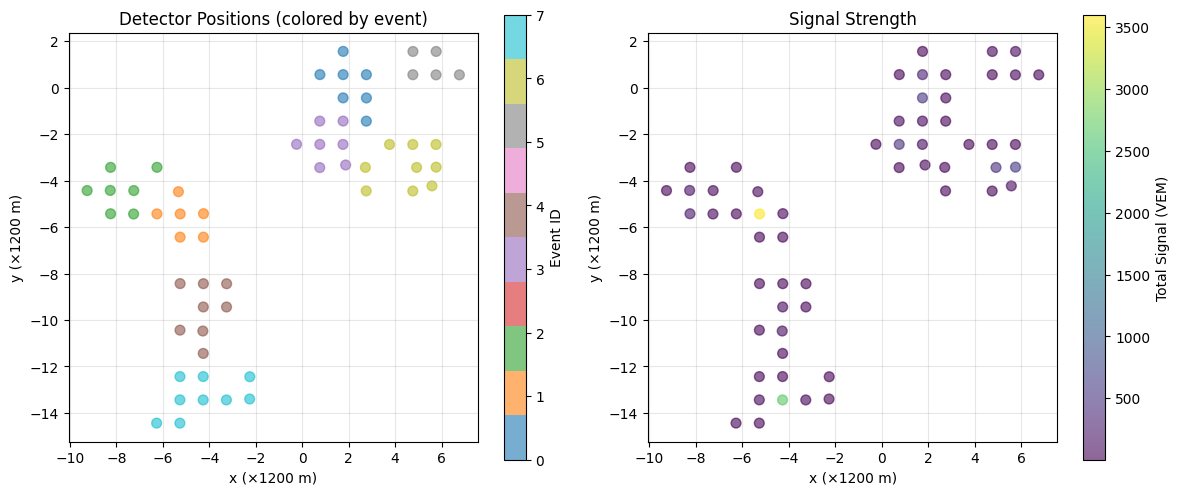

In [11]:
import matplotlib.pyplot as plt

# Get a batch
for batch in loader:
    break

# Plot detector positions colored by event
plt.figure(figsize=(12, 5))

# Positions
plt.subplot(1, 2, 1)
positions = batch.x[:, :3].numpy()  # x, y, z
scatter = plt.scatter(positions[:, 0], positions[:, 1], 
                     c=batch.batch.numpy(), cmap='tab10', s=50, alpha=0.6)
plt.colorbar(scatter, label='Event ID')
plt.xlabel('x (×1200 m)')
plt.ylabel('y (×1200 m)')
plt.title('Detector Positions (colored by event)')
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)

# Signal strength
plt.subplot(1, 2, 2)
signals = batch.x[:, 3:5].sum(dim=1).numpy()  # Sum of lower+upper PMT
scatter = plt.scatter(positions[:, 0], positions[:, 1], 
                     c=signals, cmap='viridis', s=50, alpha=0.6)
plt.colorbar(scatter, label='Total Signal (VEM)')
plt.xlabel('x (×1200 m)')
plt.ylabel('y (×1200 m)')
plt.title('Signal Strength')
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook provided complete solutions for:

**Basic Dataset Class**: `__init__`, `__len__`, `__getitem__`
**Offset Management**: Two-level offsets for hits and time traces
**Data Conversion**: NumPy → PyTorch tensors
**PyG Integration**: Using `Data` objects
**DataLoader**: Batching variable-length events

You can now use these patterns for your own machine learning projects with DST data!